# Diffusion Model: SU3 matrix model

*Sep 24, 2025*

**[Javad Komijani (ETH Zurich)](mailto:jkomijani@gmail.com)**

## Diffusion process on Lie group

Implements a diffusion process as described by the following stochastic     
    differential equation (SDE)                                                 
                                                                                
$$                                                                   
    \frac{d U(t)}{dt} = \sigma(t)\, \eta(t)\, U(t)
$$

where $\sigma(t)$ is a time-dependent noise scale, and $\eta(t)$ is standard white Gaussian noise in the algebra space.
We use
$$
    \sigma(t) = \frac{\sigma_0}{\sqrt{1 - t}}
$$                
                                                                                
The reverse process is defined by an SDE that uses a learned score function 
(the gradient of the log-probability density) to iteratively denoise the    
corrupted signal and recover clean samples.
$$                                                                   
    \frac{d U(t)}{dt} = \left(-\frac{1 + r^2}{2} \sigma^2(t) s_t(U_t) +  r \sigma(t) \eta(t)\right) U_t
$$
Here $s_t$ is in Lie-algebra element, and $r$ can be time dependent too. As two spatial cases, we can set $r$ to 0 or to 1.

Below, we define a simple neural network for the score function.

# Example: SU(3)

## Data for training and test

We use `normlfow` package to generate samples for training the flow-matching model.
We use a pre-trained `normflow` model to generate $64 \times 1024$ samples, where 4096
samples will be used for training and the rest for making histograms.

In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

In [2]:
from normflow import Model as NormflowModel

from normflow.action import MatrixAction

from normflow.prior import SUnPrior
from normflow.prior import NormalPrior

In [3]:
from normflow.nn import MultiChannelModule_
from normflow.nn import MatrixModule_
from normflow.nn import UnityDistConvertor_

from normflow.lib.matrix_handles import SU2MatrixParametrizer
from normflow.lib.matrix_handles import SU3MatrixParametrizer


def assemble_net(*, n_c, knots_len):
    
    if n_c == 2:
        par_net_ = UnityDistConvertor_(knots_len)
        matrix_handle = SU2MatrixParametrizer()
        
    elif n_c == 3:
        par_net_ = MultiChannelModule_(
            [UnityDistConvertor_(knots_len),
             UnityDistConvertor_(knots_len, symmetric=True)]
        )
        matrix_handle = SU3MatrixParametrizer()

    return MatrixModule_(par_net_, matrix_handle=matrix_handle)

In [4]:
def make_normflow_model(n_c, beta, knots_len=4):
    # Define the prior distribution
    prior = SUnPrior(n=n_c, shape=(1,))
    
    # Define the action
    action = MatrixAction(beta=beta)
    
    # Initialize the neural network for transformations
    net_ = assemble_net(n_c=n_c, knots_len=knots_len)
    
    # Create the Model with the defined components
    nf_model = NormflowModel(net_=net_, prior=prior, action=action)

    print("number of model parameters =", nf_model.net_.npar)
    
    return nf_model


# Instantiate the model
nf_model =  make_normflow_model(n_c=3, beta=6, knots_len=4)

number of model parameters = 20


In [5]:
train_the_model = False

if train_the_model:
    nf_model.train(n_epochs=5000, batch_size=1024, checkpoint_dict=dict(print_every=100))

else:
    weights_blob = 'UEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAQABIAYXJjaGl2ZS9kYXRhLnBrbEZCDgBaWlpaWlpaWlpaWlpaWoACY2NvbGxlY3Rpb25zCk9yZGVyZWREaWN0CnEAKVJxAShYFgAAAHBhcmFtX25ldF8uMC53ZWlnaHRzX3hxAmN0b3JjaC5fdXRpbHMKX3JlYnVpbGRfdGVuc29yX3YyCnEDKChYBwAAAHN0b3JhZ2VxBGN0b3JjaApEb3VibGVTdG9yYWdlCnEFWAEAAAAwcQZYAwAAAGNwdXEHSwN0cQhRSwBLA4VxCUsBhXEKiWgAKVJxC3RxDFJxDVgWAAAAcGFyYW1fbmV0Xy4wLndlaWdodHNfeXEOaAMoKGgEaAVYAQAAADFxD2gHSwN0cRBRSwBLA4VxEUsBhXESiWgAKVJxE3RxFFJxFVgWAAAAcGFyYW1fbmV0Xy4wLndlaWdodHNfZHEWaAMoKGgEaAVYAQAAADJxF2gHSwR0cRhRSwBLBIVxGUsBhXEaiWgAKVJxG3RxHFJxHVgWAAAAcGFyYW1fbmV0Xy4xLndlaWdodHNfeHEeaAMoKGgEaAVYAQAAADNxH2gHSwN0cSBRSwBLA4VxIUsBhXEiiWgAKVJxI3RxJFJxJVgWAAAAcGFyYW1fbmV0Xy4xLndlaWdodHNfeXEmaAMoKGgEaAVYAQAAADRxJ2gHSwN0cShRSwBLA4VxKUsBhXEqiWgAKVJxK3RxLFJxLVgWAAAAcGFyYW1fbmV0Xy4xLndlaWdodHNfZHEuaAMoKGgEaAVYAQAAADVxL2gHSwR0cTBRSwBLBIVxMUsBhXEyiWgAKVJxM3RxNFJxNXV9cTZYCQAAAF9tZXRhZGF0YXE3aAApUnE4KFgAAAAAcTl9cTpYBwAAAHZlcnNpb25xO0sBc1gKAAAAcGFyYW1fbmV0X3E8fXE9aDtLAXNYDAAAAHBhcmFtX25ldF8uMHE+fXE/aDtLAXNYFAAAAHBhcmFtX25ldF8uMC5zb2Z0bWF4cUB9cUFoO0sBc1gVAAAAcGFyYW1fbmV0Xy4wLnNvZnRwbHVzcUJ9cUNoO0sBc1gMAAAAcGFyYW1fbmV0Xy4xcUR9cUVoO0sBc1gUAAAAcGFyYW1fbmV0Xy4xLnNvZnRtYXhxRn1xR2g7SwFzWBUAAABwYXJhbV9uZXRfLjEuc29mdHBsdXNxSH1xSWg7SwFzdXNiLlBLBwjU+EF3VwMAAFcDAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAABcAJABhcmNoaXZlLy5mb3JtYXRfdmVyc2lvbkZCIABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWjFQSwcIt+/cgwEAAAABAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAaADcAYXJjaGl2ZS8uc3RvcmFnZV9hbGlnbm1lbnRGQjMAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaNjRQSwcIP3dx6QIAAAACAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAARAD8AYXJjaGl2ZS9ieXRlb3JkZXJGQjsAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpsaXR0bGVQSwcIhT3jGQYAAAAGAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAOAD4AYXJjaGl2ZS9kYXRhLzBGQjoAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWu4zqrhXINs/Qe+nfFfn0j8IbsJaPETZv1BLBwjzybdPGAAAABgAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4ALABhcmNoaXZlL2RhdGEvMUZCKABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpafG4LOvOY0r+Oh2jm97qAv2iFUi/rXcs/UEsHCM2cvv0YAAAAGAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgAsAGFyY2hpdmUvZGF0YS8yRkIoAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpCJQcxCtvwv0+0H9IoNOm/4mbzz3oh4j/HHP7mM4IFQFBLBwhsvbgiIAAAACAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4AJABhcmNoaXZlL2RhdGEvM0ZCIABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWtGKi96E4Yk/bnsf90gXRD9OCOwmFpaQv1BLBwjnadIsGAAAABgAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4ALABhcmNoaXZlL2RhdGEvNEZCKABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaz+J1Uc7Thr+7DLFbfG5hP603Evt6aY0/UEsHCKLoL9wYAAAAGAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgAsAGFyY2hpdmUvZGF0YS81RkIoAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpVV3wk7+yvv0sXEtf/RaG/3G2ZKEYqoD9QEmcMwBGyP1BLBwjcTkhdIAAAACAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA8AIwBhcmNoaXZlL3ZlcnNpb25GQh8AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWjMKUEsHCNGeZ1UCAAAAAgAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAAHgAyAGFyY2hpdmUvLmRhdGEvc2VyaWFsaXphdGlvbl9pZEZCLgBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaMTExMTg5NzkxMTA1NTMwMjYxMDExMzEwNzYwNTQ5NzQzNTAxODI5N1BLBwg/Dky1KAAAACgAAABQSwECAAAAAAgIAAAAAAAA1PhBd1cDAABXAwAAEAAAAAAAAAAAAAAAAAAAAAAAYXJjaGl2ZS9kYXRhLnBrbFBLAQIAAAAACAgAAAAAAAC379yDAQAAAAEAAAAXAAAAAAAAAAAAAAAAAKcDAABhcmNoaXZlLy5mb3JtYXRfdmVyc2lvblBLAQIAAAAACAgAAAAAAAA/d3HpAgAAAAIAAAAaAAAAAAAAAAAAAAAAABEEAABhcmNoaXZlLy5zdG9yYWdlX2FsaWdubWVudFBLAQIAAAAACAgAAAAAAACFPeMZBgAAAAYAAAARAAAAAAAAAAAAAAAAAJIEAABhcmNoaXZlL2J5dGVvcmRlclBLAQIAAAAACAgAAAAAAADzybdPGAAAABgAAAAOAAAAAAAAAAAAAAAAABYFAABhcmNoaXZlL2RhdGEvMFBLAQIAAAAACAgAAAAAAADNnL79GAAAABgAAAAOAAAAAAAAAAAAAAAAAKgFAABhcmNoaXZlL2RhdGEvMVBLAQIAAAAACAgAAAAAAABsvbgiIAAAACAAAAAOAAAAAAAAAAAAAAAAACgGAABhcmNoaXZlL2RhdGEvMlBLAQIAAAAACAgAAAAAAADnadIsGAAAABgAAAAOAAAAAAAAAAAAAAAAALAGAABhcmNoaXZlL2RhdGEvM1BLAQIAAAAACAgAAAAAAACi6C/cGAAAABgAAAAOAAAAAAAAAAAAAAAAACgHAABhcmNoaXZlL2RhdGEvNFBLAQIAAAAACAgAAAAAAADcTkhdIAAAACAAAAAOAAAAAAAAAAAAAAAAAKgHAABhcmNoaXZlL2RhdGEvNVBLAQIAAAAACAgAAAAAAADRnmdVAgAAAAIAAAAPAAAAAAAAAAAAAAAAADAIAABhcmNoaXZlL3ZlcnNpb25QSwECAAAAAAgIAAAAAAAAPw5MtSgAAAAoAAAAHgAAAAAAAAAAAAAAAACSCAAAYXJjaGl2ZS8uZGF0YS9zZXJpYWxpemF0aW9uX2lkUEsGBiwAAAAAAAAAHgMtAAAAAAAAAAAADAAAAAAAAAAMAAAAAAAAAPsCAAAAAAAAOAkAAAAAAABQSwYHAAAAADMMAAAAAAAAAQAAAFBLBQYAAAAADAAMAPsCAAA4CQAAAAA='
    nf_model.net_.set_weights_blob(weights_blob)

#### Generate data for diffusion model

Generate 64 * 1024 samples, use 4096 for training and all for making histograms.

In [6]:
nf_samples = nf_model.mcmc.sample(1024 * 64)

print("acceptance rate of normflow model: %.4g" % nf_model.mcmc.history.accept_rate[-1])

acceptance rate of normflow model: 0.9901


In [7]:
training_samples = nf_samples[4096::15]

print("shape of training data", training_samples.shape)

shape of training data torch.Size([4096, 1, 3, 3])


In [8]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

batch_size = 256

dataset = TensorDataset(training_samples)
data_loader = DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle = False
)

## Define a `DiffusionProcess`

A **diffusion process** contains a neural network that models **score function**,
which can be used to perform the reverse process.

Before we continue, let us create a dummy `DiffusionProcess` without any score
function and see the effect of the diffusion process.

In [9]:
from lattice_ml.diffusion.gauge import SUnDiffusionProcess

sigma_0 = 1

diffusion_process = SUnDiffusionProcess(score_fn=None, sigma_0=sigma_0)

t_eval = torch.linspace(0, 1, 100)

diffused_samples = diffusion_process.forward(nf_samples, t_eval=t_eval)

diffused_samples = torch.stack(diffused_samples, dim=0).squeeze(2)

In [10]:
from lattice_ml.linalg import eigu

grab = lambda x: x.detach().cpu().numpy()

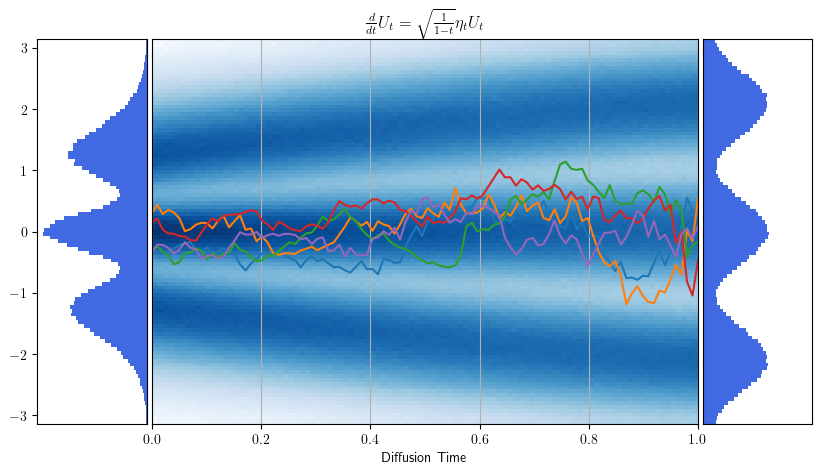

In [11]:
def plot_3subplots_diffusion(t_eval, x_eval):

    fig, axs = plt.subplots(1, 3, figsize=(10, 5), gridspec_kw={'width_ratios': [0.2, 1, 0.2]})

    theta = eigu(x_eval)[0].angle()
    theta = grab(theta)
    shape = theta.shape
    t_eval_reshaped = np.tile(t_eval[:, None], (1, np.prod(shape[1:]))).reshape(*shape)
    
    axs[1].hist2d(t_eval_reshaped.ravel(), theta.ravel(),  norm=mpl.colors.PowerNorm(0.5), cmap='Blues', bins=100)
    
    hist_kwargs = dict(bins=100, color='royalblue', density=True, orientation='horizontal')

    axs[0].hist(theta[0].ravel(), label=r'$U_0$', **hist_kwargs)
    axs[2].hist(theta[-1].ravel(), label=r'$U_1$', **hist_kwargs)
    axs[0].invert_xaxis()  # Invert x-axis to place histogram to the left

    # Remove undesired axis ticks and labels
    axs[1].set_yticks([])
    axs[2].set_yticks([])
    axs[0].set_xticks([])
    axs[2].set_xticks([])

    # Add title & labels
    axs[1].set_title(r"$\frac{d}{dt} U_t = \sqrt{\frac{%g}{1 - t}} \eta_t U_t$" % sigma_0**2)
    axs[1].set_xlabel('Diffusion Time')
    axs[1].grid()

    # Set ylim
    axs[0].set_ylim([-np.pi, np.pi])
    axs[1].set_ylim([-np.pi, np.pi])
    axs[2].set_ylim([-np.pi, np.pi])
    axs[0].set_xlim([0.45, 0])
    axs[2].set_xlim([0, 0.45])

    # Decrease horizontal spacing between subplots
    plt.subplots_adjust(wspace=0.02)

    for k in range(5):
        ind = np.random.randint(0, t_eval_reshaped.shape[1])
        axs[1].plot(t_eval_reshaped[:, ind, 2], theta[:, ind, 2])

    return fig, axs


fig, axs = plot_3subplots_diffusion(t_eval, diffused_samples)
# fig.savefig("flow_matching.jpg")

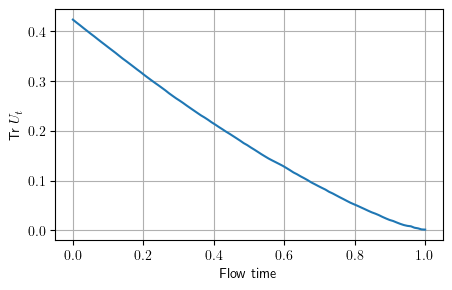

In [12]:
def plot_trace(t_eval, x_eval, label=None, ax=None):

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 3))

    bsize = len(t_eval)
    trace_mean = x_eval.diagonal(dim1=-2, dim2=-1).mean(dim=-1, keepdim=True)

    ax.plot(t_eval, trace_mean.reshape(bsize, -1).mean(dim=-1).real, label=label)

    ax.set_xlabel(r"Flow time")
    ax.set_ylabel(r"Tr~$U_t$")
    ax.grid()
    if label is not None:
        ax.legend()
        

plot_trace(t_eval, diffused_samples)

### Designing score function

The flow is defined as
The reverse process is defined by an SDE that uses a learned score function 
(the gradient of the log-probability density) to iteratively denoise the    
corrupted signal and recover clean samples.
$$                                                                   
    \frac{d U(t)}{dt} = \left(-\frac{1 + r^2}{2} \sigma^2(t) s_t(U_t) +  r \sigma(t) \eta(t)\right) U_t
$$
Here $s_t$ is in Lie-algebra element, and $r$ can be time dependent too. As two spatial cases, we can set $r$ to 0 or to 1.

Below, we define a simple neural network for the score function.

In [13]:
def make_traceless(matrix: torch.Tensor) -> torch.Tensor:
    """Removes the trace component from a square matrix."""
    # Compute the mean trace across the last two dimensions
    trace_mean = matrix.diagonal(dim1=-2, dim2=-1).mean(dim=-1, keepdim=True)
    
    # Subtract the mean trace from the diagonal elements
    return matrix - torch.diag_embed(trace_mean.expand(matrix.shape[:-1]))


sigma_schedule = diffusion_process.sigma_schedule


class SU3AlgScoreFunc(torch.nn.Module):
    """
    An algebra-element score function for SU(3) matrices.

    This model takes as input the time `t` and the initial state matrix `x` and
    predicts a flow while ensuring the output remains antihermitian and traceless.

    The network consists of fully connected layers with SiLU activations.

    Attributes:
        net: A sequential model composed of linear layers and activations.
    """

    def __init__(self, hidden_sizes: list[int] = [32, 32, 32, 32]):
        """Initializes the SU2DynamicsFunc neural network."""
        super().__init__()

        in_features = 1 + 18  # t & 3x3 complex matrix: 1 + 3 x 3 x 2
        out_features = 18  # 3x3 complex matrix: 3 x 3 x 2
        layer_sizes = [in_features, *hidden_sizes, out_features]
        layers = []

        # Construct the network layers
        for i in range(len(layer_sizes) - 1):
            layers.append(torch.nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(layer_sizes) - 2:  # No activation for the last layer
                layers.append(torch.nn.SiLU())

        self.net = torch.nn.Sequential(*layers)

    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        Computes the algebra-element score function for SU(3) matrices.

        Given a time `t` and a matrix `x`, the function processes the input
        through the neural network and applies post-processing to ensure the
        output is antihermitian and traceless.

        Args:
            - t (torch.Tensor): A 0D or 1D tensor representing time.
              If 1D, it is of shape (batch_size,)
            - x (torch.Tensor): A complex-valued input tensor of shape
              (batch_size, 1, 3, 3).

        Returns:
            - torch.Tensor: A antihermitian, traceless tensor of shape
              (batch_size, 1, 3, 3).
        """
        # Ensure t is a batch tensor
        if t.ndim == 0:
            t = t.repeat(x.shape[0])

        # Reshape x and extract real & imaginary parts as features
        x_flattened = x.reshape(-1, 9)
        x = torch.cat([t[:, None], x_flattened.real, x_flattened.imag], dim=-1)

        # Forward pass through the network
        x = self.net(x)

        # Convert the output to a complex tensor with appropriate shape
        x = torch.view_as_complex(x.reshape(-1, 1, 3, 3, 2))

        sigma_t = sigma_schedule(t).reshape(-1, *[1] * (x.ndim - 1)) 

        # Ensure the output is antihermitian and traceless
        return make_traceless(x - x.adjoint()) / sigma_t ** 2

In [14]:
# Now the build the model

diffusion_process = SUnDiffusionProcess(SU3AlgScoreFunc(), sigma_0=sigma_0)

In [15]:
from functools import partial

n_epochs = 300

train_kwargs = dict(
    n_epochs = n_epochs,
    hyperparam = dict(lr=0.001),
    checkpoint_dict = dict(print_every=50),
    scheduler = partial(
        torch.optim.lr_scheduler.CosineAnnealingLR,                     
        T_max = int(1.01 * n_epochs)                                    
    )
)

In [16]:
diffusion_process.train(data_loader, **train_kwargs)

18:15:22 | Training started for 300 epochs
18:15:30 | Epoch: 50 | loss: 0.8262
18:15:37 | Epoch: 100 | loss: 0.8231
18:15:41 | Epoch: 150 | loss: 0.8337
18:15:45 | Epoch: 200 | loss: 0.8325
18:15:49 | Epoch: 250 | loss: 0.8187
18:15:53 | Epoch: 300 | loss: 0.8362
18:15:53 | Training finished (cpu); TIME = 30.4 s


Text(0, 0.5, 'Loss')

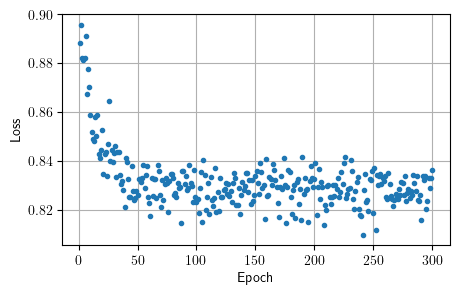

In [17]:
fig, axs = plt.subplots(1, 1, figsize=(5, 3))

loss = diffusion_process.trainer.train_history['loss']
epochs = np.arange(1, len(loss) + 1)
plt.plot(epochs, loss, '.')

plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [18]:
x = nf_model.prior.sample(1024 * 32)

t_eval = torch.linspace(1, 0, 100)


with torch.no_grad():
    y_eval = diffusion_process.reverse(x, rev2fwd_noise_ratio=1, step_size=0.01, t_eval=t_eval)


y = y_eval[-1]  # This is the state at the final time of t_eval, i.e. at t = 0

In [19]:
theta_x = grab(eigu(x)[0].angle())
theta_y = grab(eigu(y)[0].angle())

theta_test = grab(eigu(nf_samples)[0].angle())

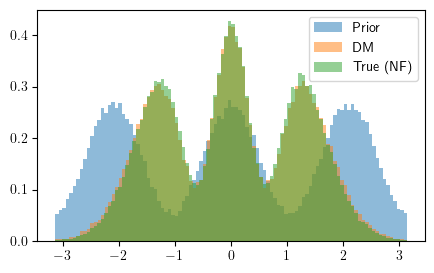

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

plt.hist(theta_x.ravel(), label = 'Prior', bins=100, density=True, alpha=0.5)
plt.hist(theta_y.ravel(), label = 'DM', bins=100, density=True, alpha=0.5)
plt.hist(theta_test.ravel(), label = 'True (NF)', bins=100, density=True, alpha=0.5)

plt.legend();

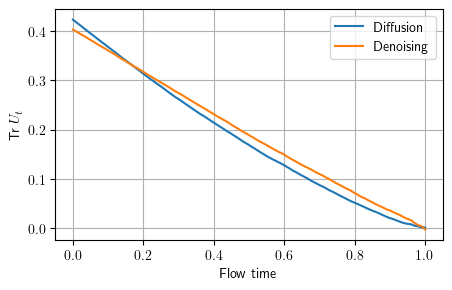

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))


t_eval = torch.flip(t_eval, dims=(0,))
denoised_samples = torch.flip(torch.stack(y_eval, dim=0).squeeze(2), dims=(0,))

plot_trace(t_eval, diffused_samples, label='Diffusion', ax=ax)
plot_trace(t_eval, denoised_samples, label='Denoising', ax=ax)

ax.grid()

# fig, axs = plot_3subplots_diffusion(t_eval, denoised_samples)